Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.holtwinters import SimpleExpSmoothing

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

Load Dataset

In [3]:
df = pd.read_csv('/content/raw_orders_coffee.csv')

df.head()

,Order_ID,Date,Type,Customer,Customer_ID,Customer_DOB,Customer_Membership_Status,Products,Quantities,Prices,Discount_Code
0,1269,08/07/2025,Deliveroo,Se Ra Raab,461,19/04/2003,Non-Member,"c(""Macchiato"", ""Large Size"")","c(1, 1)","c(3.8, 0.5)",NaN
1,3335,01/07/2025,Dine In,Carie Gomez-Rojas,239,09/05/1982,Non-Member,"c(""Macchiato"")",c(1),c(3.8),NaN
2,3068,21/08/2025,Deliveroo,James Wolfe,440,09/08/1980,Non-Member,"c(""Frappuccino"", ""Extra Shot"")","c(1, 1)","c(4.5, 0.6)",NaN
3,3428,04/05/2025,Deliveroo,Joseph Jackson,220,28/06/1993,Member,"c(""Iced Latte"", ""Almond Milk"")","c(2, 1)","c(3.75, 0.5)",OFF5
4,1537,06/08/2025,Dine In,Samantha Prim,497,03/09/1994,Non-Member,"c(""Cold Brew"", ""Bagel"", ""Brownie"")","c(2, 1, 1)","c(3.25, 2.5, 2.5)",OFF5


Dataset Information

In [4]:
print("Shape:", df.shape)

df.info()

Shape: (4000, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Order_ID                    4000 non-null   int64 
 1   Date                        4000 non-null   object
 2   Type                        4000 non-null   object
 3   Customer                    4000 non-null   object
 4   Customer_ID                 4000 non-null   int64 
 5   Customer_DOB                4000 non-null   object
 6   Customer_Membership_Status  4000 non-null   object
 7   Products                    4000 non-null   object
 8   Quantities                  4000 non-null   object
 9   Prices                      4000 non-null   object
 10  Discount_Code               598 non-null    object
dtypes: int64(2), object(9)
memory usage: 343.9+ KB


Convert Date Column

In [5]:
df['Date'] = pd.to_datetime(
    df['Date'],
    dayfirst=True
)

Create Daily Orders Dataset

SES needs one variable.

Convert order-level data to daily orders.

In [6]:
daily_orders = df.groupby(
    'Date'
).size().reset_index(
    name='Orders'
)

daily_orders.head()

,Date,Orders
0,2025-05-01,44
1,2025-05-02,30
2,2025-05-03,40
3,2025-05-04,33
4,2025-05-05,40


Check Total Days

In [7]:
print("Total Days :", len(daily_orders))

print("Start Date :", daily_orders['Date'].min())

print("End Date :", daily_orders['Date'].max())

Total Days : 123
Start Date : 2025-05-01 00:00:00
End Date : 2025-08-31 00:00:00


Set Date as Index

In [8]:
daily_orders.set_index(
    'Date',
    inplace=True
)

daily_orders.head()

,Orders
Date,
2025-05-01,44
2025-05-02,30
2025-05-03,40
2025-05-04,33
2025-05-05,40


Check Missing Values

In [9]:
daily_orders.isnull().sum()

,0
Orders,0


Plot Daily Orders

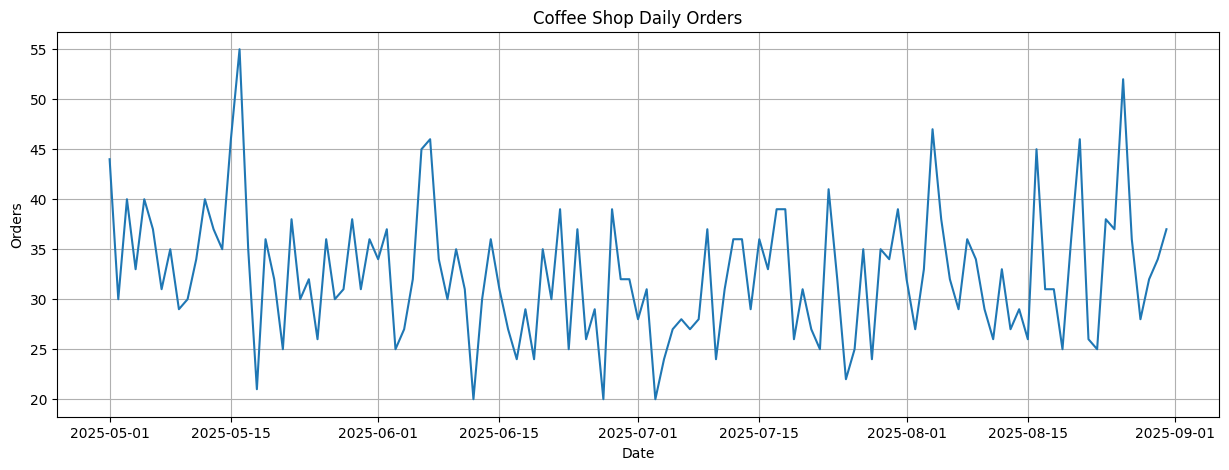

In [10]:
plt.figure(figsize=(15,5))

plt.plot(
    daily_orders['Orders']
)

plt.title(
    'Coffee Shop Daily Orders'
)

plt.xlabel('Date')
plt.ylabel('Orders')

plt.grid(True)

plt.show()

| Observation                        | Interpretation                         |
| ---------------------------------- | -------------------------------------- |
| Orders fluctuate between 20 and 55 | Daily demand changes frequently        |
| No strong upward trend             | Orders are relatively stable over time |
| No strong downward trend           | Business demand is not declining       |
| Peaks around 50–55 orders          | High-demand days occurred              |
| Lowest values around 20 orders     | Low-demand days occurred               |
| Average range 30–40 orders         | Typical daily order volume             |

============

| Condition                   | Result        |
| --------------------------- | ------------- |
| Single Variable             | ✅ Orders Only |
| Strong Trend Present?       | ❌ No          |
| Strong Seasonality Present? | ❌ No          |
| Stable Demand Pattern?      | ✅ Yes         |
| Suitable for SES?           | ✅ Yes         |

============

The graph shows random fluctuations around a stable average level without a clear trend or seasonal pattern. Therefore, Simple Exponential Smoothing (SES) is an appropriate forecasting model.

Train-Test Split

In [11]:
train_size = int(
    len(daily_orders)*0.80
)

train = daily_orders.iloc[:train_size]

test = daily_orders.iloc[train_size:]

print("Train :", train.shape)

print("Test :", test.shape)

Train : (98, 1)
Test : (25, 1)


Build SES Model

In [12]:
model = SimpleExpSmoothing(
    train['Orders']
)

model

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


| Output             | Meaning                        |
| ------------------ | ------------------------------ |
| SimpleExpSmoothing | SES model selected             |
| train['Orders']    | Daily orders used for training |
| 0x7cace8dbf4d0     | Memory address of model object |
| Error?             | ❌ No                           |
| Model Created?     | ✅ Yes                          |
| Model Trained?     | ❌ Not yet                      |


Train SES Model

In [13]:
model_fit = model.fit(
    optimized=True
)

print(
    model_fit.summary()
)

                       SimpleExpSmoothing Model Results                       
Dep. Variable:                 Orders   No. Observations:                   98
Model:             SimpleExpSmoothing   SSE                           4201.572
Optimized:                       True   AIC                            372.308
Trend:                           None   BIC                            377.478
Seasonal:                        None   AICC                           372.738
Seasonal Periods:                None   Date:                 Sat, 20 Jun 2026
Box-Cox:                        False   Time:                         07:34:06
Box-Cox Coeff.:                  None                                         
                       coeff                 code              optimized      
------------------------------------------------------------------------------
smoothing_level            0.1683711                alpha                 True
initial_level              44.000000                

Forecast Test Data

In [14]:
forecast = model_fit.forecast(
    len(test)
)

forecast.head()

,0
2025-08-07,34.377342
2025-08-08,34.377342
2025-08-09,34.377342
2025-08-10,34.377342
2025-08-11,34.377342


Actual vs Forecast Graph

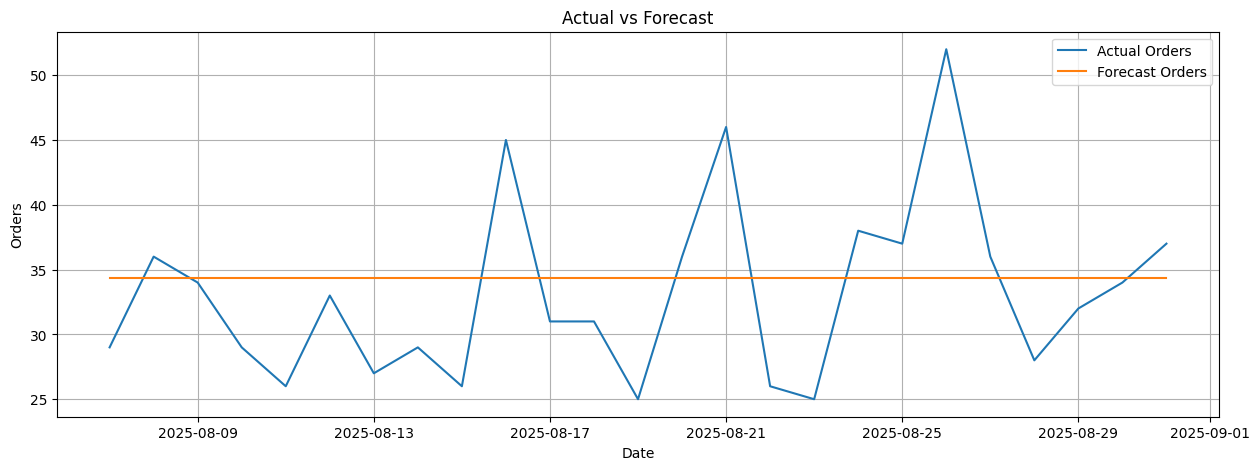

In [15]:
plt.figure(figsize=(15,5))

plt.plot(
    test.index,
    test['Orders'],
    label='Actual Orders'
)

plt.plot(
    test.index,
    forecast,
    label='Forecast Orders'
)

plt.title(
    'Actual vs Forecast'
)

plt.xlabel('Date')

plt.ylabel('Orders')

plt.legend()

plt.grid(True)

plt.show()

Why is the Forecast a Straight Line?

SES formula gives more importance to the latest smoothed value.

Since:

Trend = None
Seasonality = None

The model assumes:

Future demand will be approximately equal to the recent average demand.

Therefore:

Forecast Day 1 = 34.5
Forecast Day 2 = 34.5
Forecast Day 3 = 34.5
...

All future values become nearly the same.

===============

**Business Interpretation**

| Result                 | Meaning                       |
| ---------------------- | ----------------------------- |
| Average Orders ≈ 34–35 | Expected daily demand         |
| No Strong Trend        | Business is stable            |
| No Seasonality         | Demand is consistent          |
| Spikes Are Random      | Difficult to predict with SES |

================

Model Strengths

| Strength             | Reason                               |
| -------------------- | ------------------------------------ |
| Simple               | Easy to implement                    |
| Fast                 | Very low computation                 |
| Good for Stable Data | Matches your dataset characteristics |
| Good Baseline Model  | Useful comparison model              |

=================

SES is suitable for short-term forecasting of stable coffee shop demand

Calculate MAE

In [16]:
mae = mean_absolute_error(
    test['Orders'],
    forecast
)

print("MAE :", mae)

MAE : 5.5456558595767005


Calculate RMSE

In [17]:
rmse = np.sqrt(
    mean_squared_error(
        test['Orders'],
        forecast
    )
)

print("RMSE :", rmse)

RMSE : 6.9055419627473045


Metrics Table

In [18]:
metrics_table = pd.DataFrame({
    'Metric':['MAE','RMSE'],
    'Value':[mae,rmse]
})

metrics_table

,Metric,Value
0,MAE,5.545656
1,RMSE,6.905542


| Metric         | Answer                                                                           |
| -------------- | -------------------------------------------------------------------------------- |
| MAE            | The average forecast error is 5.55 orders per day.                               |
| RMSE           | The root mean square error is 6.91 orders.                                       |
| Interpretation | Forecast errors are relatively small compared to the average daily demand.       |
| Conclusion     | The SES model provides satisfactory short-term forecasts for coffee shop orders. |


Forecast Next 7 Days

In [19]:
future_forecast = model_fit.forecast(
    steps=7
)

future_forecast

,0
2025-08-07,34.377342
2025-08-08,34.377342
2025-08-09,34.377342
2025-08-10,34.377342
2025-08-11,34.377342
2025-08-12,34.377342
2025-08-13,34.377342


Create Future Dates

In [20]:
future_dates = pd.date_range(
    start=daily_orders.index[-1],
    periods=8,
    freq='D'
)[1:]

Create Future Forecast Table

In [21]:
future_df = pd.DataFrame({
    'Forecast_Orders':
    future_forecast.values
},
index=future_dates)

future_df

,Forecast_Orders
2025-09-01,34.377342
2025-09-02,34.377342
2025-09-03,34.377342
2025-09-04,34.377342
2025-09-05,34.377342
2025-09-06,34.377342
2025-09-07,34.377342


| Observation              | Meaning                     |
| ------------------------ | --------------------------- |
| Forecast Orders ≈ 34/day | Expected daily demand       |
| No Increasing Trend      | Orders likely remain stable |
| No Decreasing Trend      | Business is not declining   |
| Stable Forecast          | Consistent customer demand  |

==========

**Forecast Summary Table**

| Metric                  | Result |
| ----------------------- | ------ |
| Forecast Horizon        | 7 Days |
| Average Forecast Orders | 34.38  |
| Trend Detected          | No     |
| Seasonality Detected    | No     |
| Demand Pattern          | Stable |
| Forecast Shape          | Flat   |
| SES Suitability         | High   |
